In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import kagglehub

In [58]:
kagglehub.dataset_download('lorenzoscaturchio/spotify-tracks-audio-features-50k', output_dir='./kagglesourcefiles')
# this will download the dataset, readME file, and explore file - from kaggle source.
# if you only want the dataset, you can just ignore this cell and run the next cell.
# kagglesourcefiles - ignored on commit

100%|██████████| 6.56M/6.56M [00:00<00:00, 28.3MB/s]

Extracting files...


'./kagglesourcefiles'

In [55]:
df = pd.read_csv(r'data\spotify_tracks.csv')
df.head()

,track_id,track_name,artist_name,album_name,release_year,genre,popularity,duration_ms,explicit,danceability,...,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,key,mode,time_signature
0,P3fAbnFbmOHnKYaXRvj7uf,One Dance (Acoustic Version),Alex Rodriguez,The Night Album,2024,metal,14,189042,True,0.427723,...,-4.702460,0.050635,0.239506,0.181395,0.133053,0.431384,141.048735,6,0,4
1,M2wleOV911xCZkwPRQeNHp,Forever Song (Remix),Desert Wind,Burning Soul,2019,rock,11,186805,True,0.448634,...,-7.110031,0.000000,0.044463,0.097818,0.435949,0.559135,131.833287,0,1,5
2,4JSnE2NiiUHUAKw9iEU1jj,Last Mountain,The Midnight,The Night Album,2022,k-pop,23,121814,False,0.707923,...,-7.305120,0.144091,0.118380,0.000000,0.262254,0.516873,127.132954,2,1,5
3,2UVvsjaSS8VFgM0Fmxk754,Falling Star (Live),Phantom Keys,Phantom's Greatest Hits,2024,latin,34,216049,False,0.846237,...,-9.527256,0.006668,0.272844,0.000000,0.045332,0.667911,93.041715,0,1,6
4,EeVVhDIq2AnHTmt9OBGhnu,Rising Moon (feat. someone),Desert Wind,Rising Soul,2010,latin,31,156170,False,0.943720,...,-9.017653,0.057632,0.219752,0.098044,0.132083,0.772151,93.404975,7,1,4


In [4]:
df.shape

(50000, 21)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   track_id          50000 non-null  str    
 1   track_name        50000 non-null  str    
 2   artist_name       50000 non-null  str    
 3   album_name        50000 non-null  str    
 4   release_year      50000 non-null  int64  
 5   genre             50000 non-null  str    
 6   popularity        50000 non-null  int64  
 7   duration_ms       50000 non-null  int64  
 8   explicit          50000 non-null  bool   
 9   danceability      50000 non-null  float64
 10  energy            50000 non-null  float64
 11  loudness          50000 non-null  float64
 12  speechiness       50000 non-null  float64
 13  acousticness      50000 non-null  float64
 14  instrumentalness  50000 non-null  float64
 15  liveness          50000 non-null  float64
 16  valence           50000 non-null  float64
 17  temp

Cat col: track id, track name, artist name, album name, explicit (needs to be encoded as 0 and 1)

Num col: release year (going to be need to be converted to date format), popularity, duration_ms, danceability, energy, loudness, speechiness, acousticness, instrumentalness, liveness, valence, tempo, key, mode, time_signature

In [6]:
df.isnull().sum()

track_id            0
track_name          0
artist_name         0
album_name          0
release_year        0
genre               0
popularity          0
duration_ms         0
explicit            0
danceability        0
energy              0
loudness            0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
key                 0
mode                0
time_signature      0
dtype: int64

Text(0.5, 1.0, 'Correlation Matrix of Spotify Track Features')

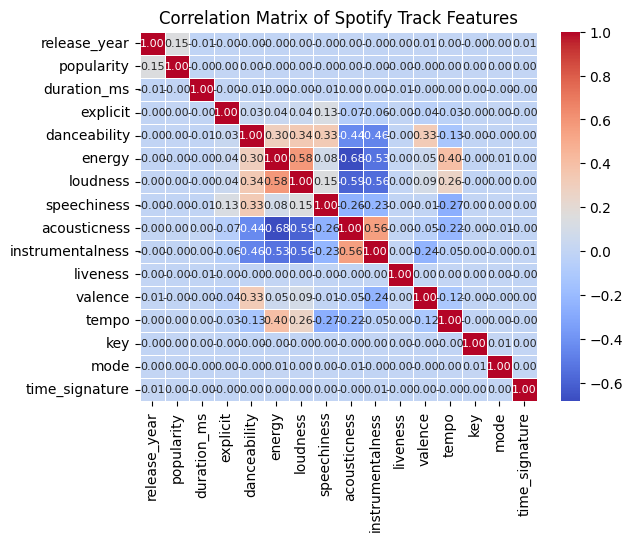

In [7]:
corr_matrix = df.corr(numeric_only=True)
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5, annot_kws={"size": 8})
plt.title('Correlation Matrix of Spotify Track Features')

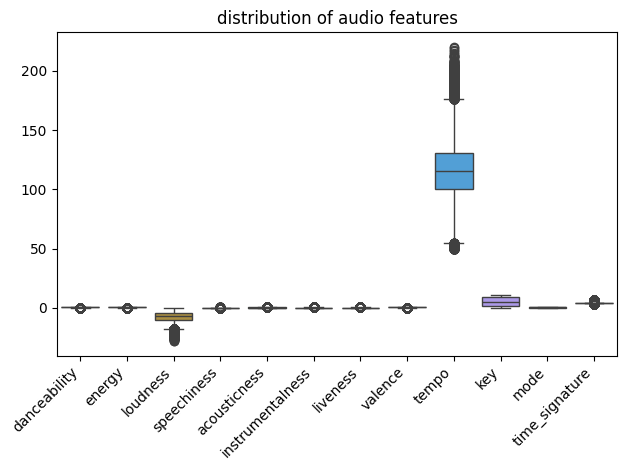

In [21]:
features = ['danceability','energy','loudness','speechiness','acousticness','instrumentalness','liveness','valence','tempo','key','mode','time_signature']
sns.boxplot(data=df[features])
plt.xticks(rotation=45, ha='right')
plt.title('distribution of audio features')
plt.tight_layout()

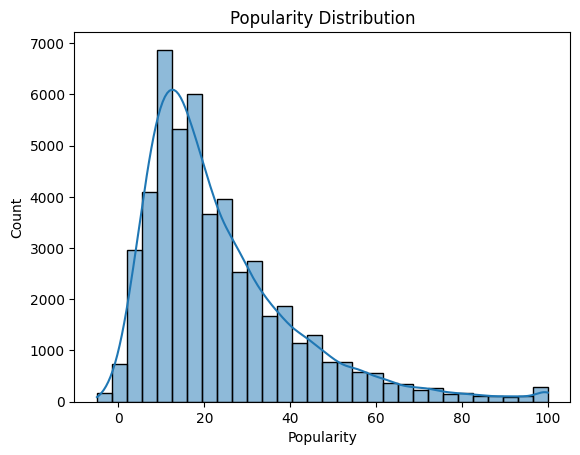

In [20]:
# shows how popularity is distributed across the dataset
sns.histplot(df['popularity'], bins=30, kde=True)
plt.title('Popularity Distribution')
plt.xlabel('Popularity')
plt.ylabel('Count')
plt.show()

C:\Users\aashu\AppData\Local\Temp\ipykernel_9340\1372907519.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title='Colors: Genre')


C:\Users\aashu\AppData\Local\Temp\ipykernel_9340\1372907519.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title='Colors: Genre')


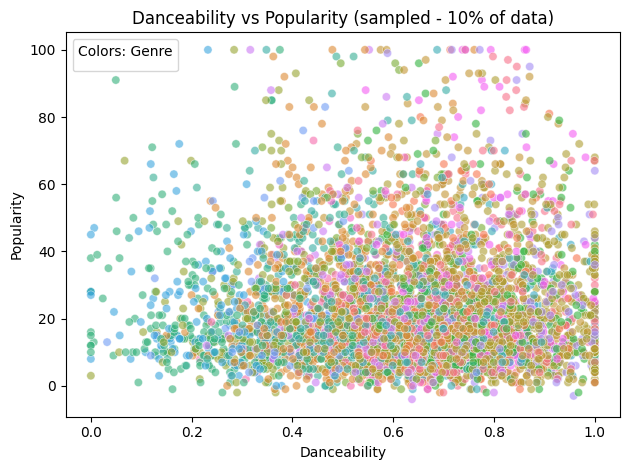

In [44]:
# Danceability vs popularity scatter (sampled for performance/readability)
sns.scatterplot(data=df.sample(5000, random_state=42), x='danceability', y='popularity', hue='genre', alpha=0.6, legend=False)
plt.title('Danceability vs Popularity (sampled - 10% of data)')
plt.xlabel('Danceability')
plt.ylabel('Popularity')
plt.legend(title='Colors: Genre')
plt.tight_layout()
plt.show()

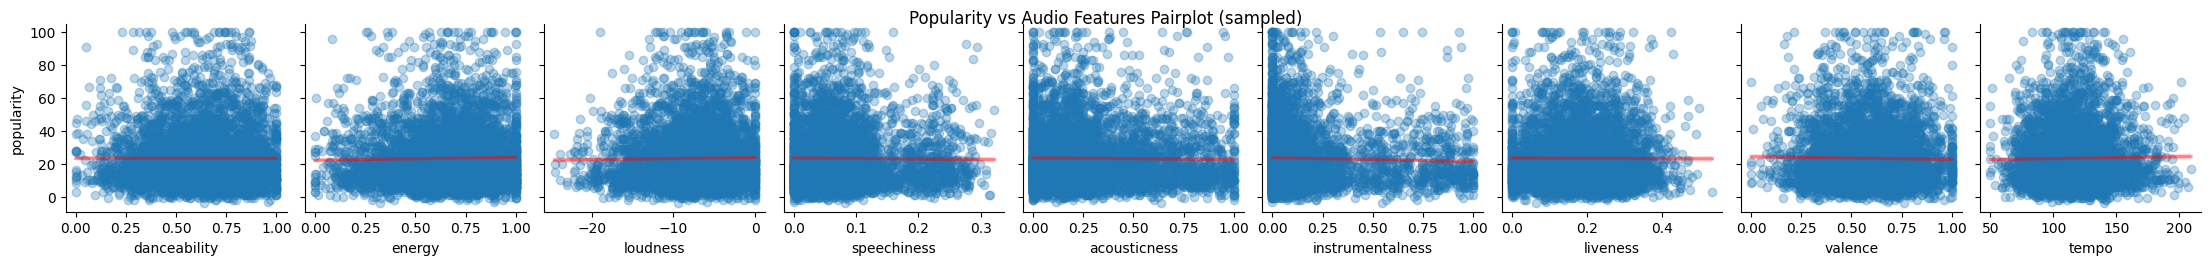

In [48]:
# Pairplot of popularity vs each audio feature only
pair_features = ['danceability','energy','loudness','speechiness','acousticness','instrumentalness','liveness','valence','tempo']

# pairplot on sample (10% of data)
sample_df = df[['popularity'] + pair_features].sample(5000, random_state=42)

sns.pairplot(sample_df, x_vars=pair_features, y_vars=['popularity'], kind='reg', plot_kws={'line_kws':{'color':'red','alpha':0.4}, 'scatter_kws':{'alpha':0.3}})
plt.suptitle('Popularity vs Audio Features Pairplot (sampled)', y=1.02)
plt.show()

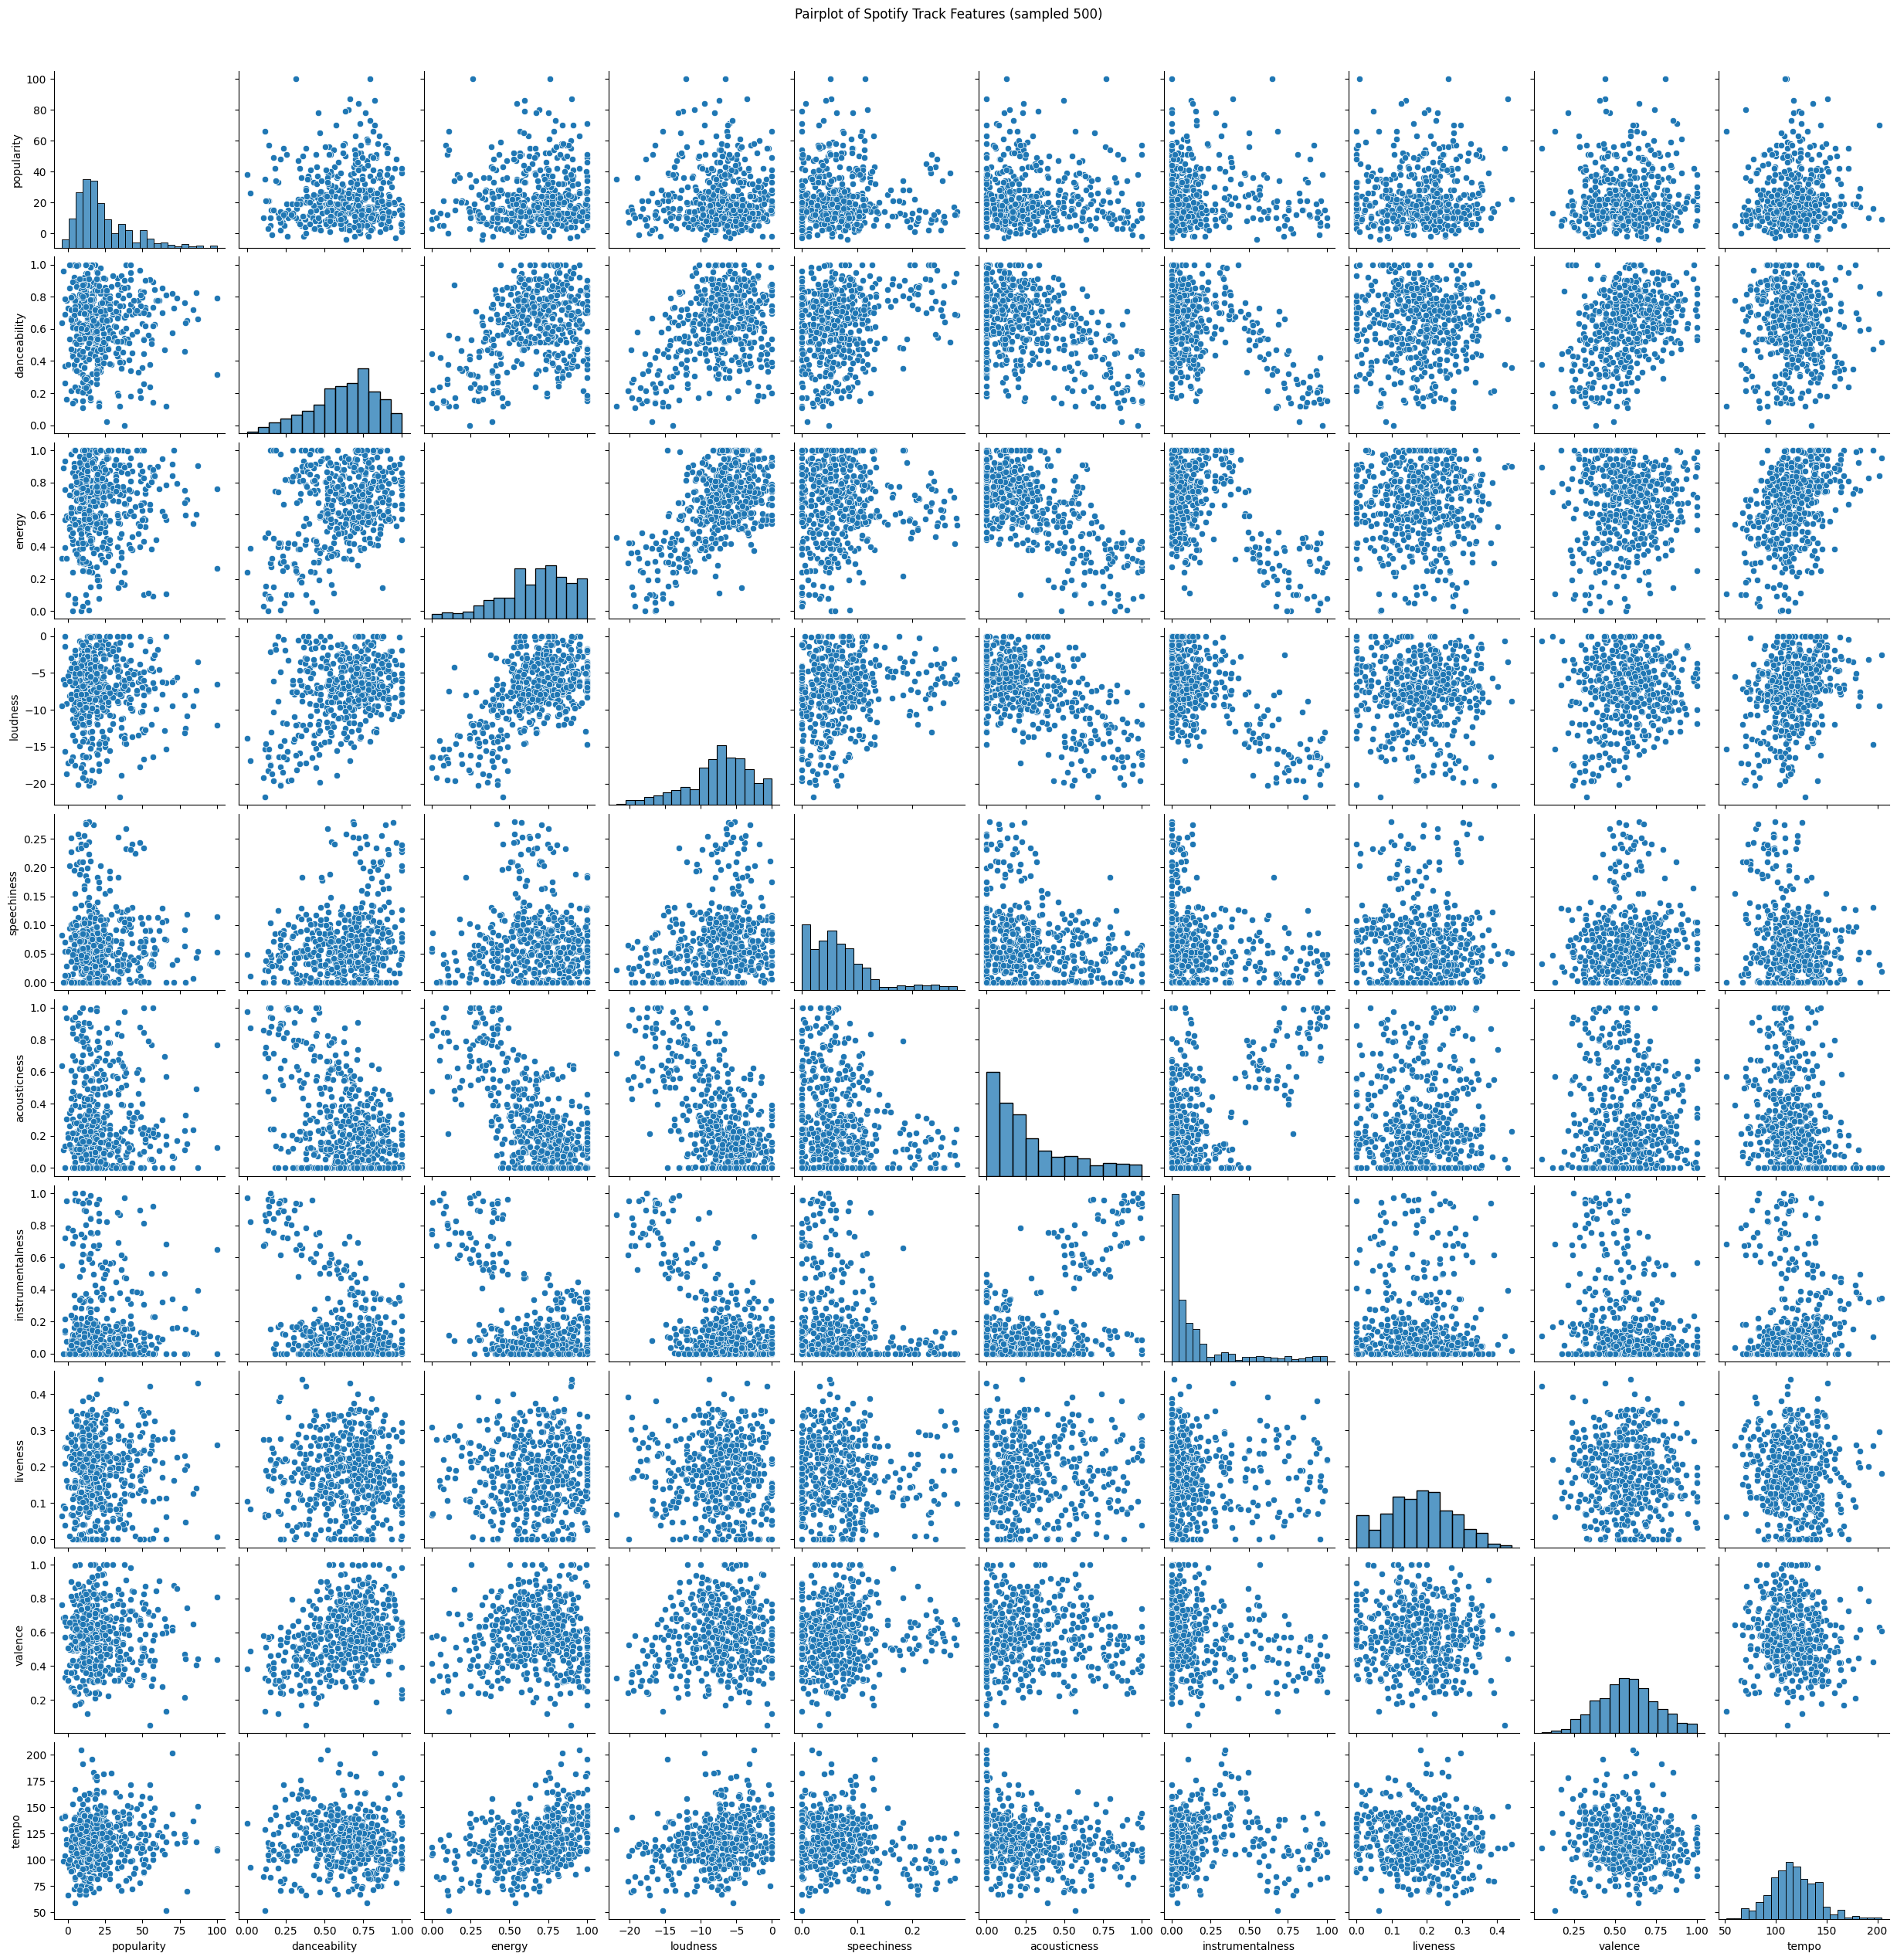

In [50]:
# Full pairplot, but with sampled subset for performance
pairplot_features = ['popularity', 'danceability', 'energy', 'loudness', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo']
sample_pairplot_df = df[pairplot_features].sample(500, random_state=42)

sns.pairplot(sample_pairplot_df)
plt.suptitle('Pairplot of Spotify Track Features (sampled 500)', y=1.02)
plt.show()